# Data Agent Session

**Task:** pull the churn data for customers and train a model to predict churn, with EDA and a chart

## Phase: setup

In [ ]:
import pandas as pd
df = pd.read_csv(r'C:\Users\KIIT0001\telecom-agents\exports\ml_dataset.csv')
print('Loaded df from CSV:', df.shape)

Loaded df from CSV: (7043, 7)


## Phase: eda

In [ ]:
df.shape

(7043, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   bool  
 3   partner         7043 non-null   bool  
 4   dependents      7043 non-null   bool  
 5   city_id         7043 non-null   int64 
 6   churn           7043 non-null   bool  
dtypes: bool(4), int64(1), object(2)
memory usage: 192.7+ KB


In [ ]:
df.describe()

           city_id
count  7043.000000
mean      3.498935
std       1.723286
min       1.000000
25%       2.000000
50%       4.000000
75%       5.000000
max       6.000000

In [ ]:
df['churn'].value_counts()

churn
False    5174
True     1869
Name: count, dtype: int64

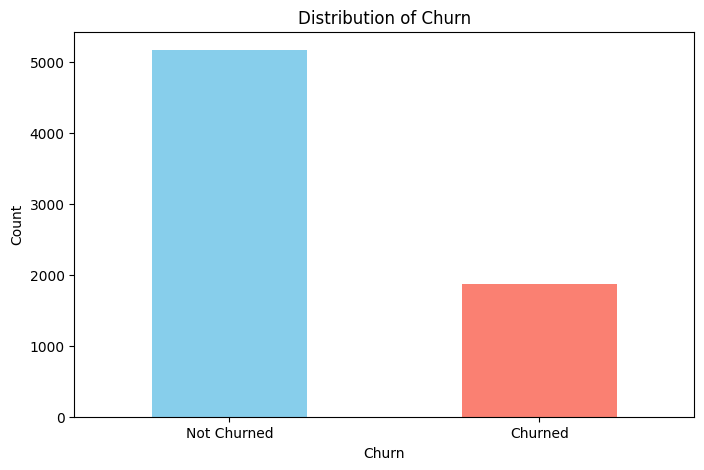

In [ ]:
import matplotlib.pyplot as plt

# Plotting the distribution of the target variable 'churn'
plt.figure(figsize=(8, 5))
df['churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Churned', 'Churned'], rotation=0)
plt.show()

In [ ]:
# Step 1: Inspect the DataFrame to understand its structure and target distribution.

df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   bool  
 3   partner         7043 non-null   bool  
 4   dependents      7043 non-null   bool  
 5   city_id         7043 non-null   int64 
 6   churn           7043 non-null   bool  
dtypes: bool(4), int64(1), object(2)
memory usage: 192.7+ KB


((7043, 7), None)

## Phase: clean

In [ ]:
# Step 2: Clean and encode the DataFrame
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Convert boolean columns to integers
for col in ['senior_citizen', 'partner', 'dependents', 'churn']:
    df[col] = df[col].astype(int)

# Use LabelEncoder for the 'gender' column
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

# One-hot encode 'city_id'
df = pd.get_dummies(df, columns=['city_id'], drop_first=True)

# Drop 'customer_id' as it is an identifier
if 'customer_id' in df.columns:
    df.drop(columns=['customer_id'], inplace=True)

## Phase: features

In [ ]:
# Step 3: Define X and y explicitly

y = df['churn'].astype(int)
X = df.drop(columns=['churn'])

# Print shapes of X and y to confirm
X.shape, y.shape

((7043, 9), (7043,))

## Phase: split

In [ ]:
# Step 4: Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print train/test shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 9), (1409, 9), (5634,), (1409,))

## Phase: train

In [ ]:
# Step 5: Train multiple models and compare their performance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score

# Initialize models
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gb_clf = GradientBoostingClassifier(learning_rate=0.1, random_state=42)

# Fit the models
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Get predictions
log_reg_preds = log_reg.predict(X_test)
rf_clf_preds = rf_clf.predict(X_test)
gb_clf_preds = gb_clf.predict(X_test)

# Calculate F1 scores
log_reg_f1 = f1_score(y_test, log_reg_preds)
rf_clf_f1 = f1_score(y_test, rf_clf_preds)
gb_clf_f1 = f1_score(y_test, gb_clf_preds)

log_reg_f1, rf_clf_f1, gb_clf_f1

(0.4731750219876869, 0.10047846889952153, 0.065)

## Phase: tune

In [ ]:
# Step 6: Tune the best model using RandomizedSearchCV for RandomForestClassifier

from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid for RandomForestClassifier
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30, 40]
}

# Initialize RandomizedSearchCV
rf_random_search = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_dist,
                                      n_iter=5, cv=3, random_state=42, scoring='f1')

# Fit the model
rf_random_search.fit(X_train, y_train)

# Get best parameters and best score
best_params = rf_random_search.best_params_
best_score = rf_random_search.best_score_

best_params, best_score

({'n_estimators': 50, 'max_depth': 30}, 0.1151929389637446)

## Phase: eval

In [ ]:
# Step 7: Evaluate the tuned model on the test set

# Use the best parameters to train the RandomForestClassifier
best_rf = RandomForestClassifier(n_estimators=best_params['n_estimators'], 
                                  max_depth=best_params['max_depth'], 
                                  random_state=42)

best_rf.fit(X_train, y_train)

# Get predictions and evaluate
best_rf_preds = best_rf.predict(X_test)
best_rf_f1 = f1_score(y_test, best_rf_preds)

from sklearn.metrics import classification_report

class_report = classification_report(y_test, best_rf_preds)

best_rf_f1, class_report

(0.10501193317422435,
 '              precision    recall  f1-score   support\n\n           0       0.74      0.98      0.84      1035\n           1       0.49      0.06      0.11       374\n\n    accuracy                           0.73      1409\n   macro avg       0.62      0.52      0.47      1409\nweighted avg       0.67      0.73      0.65      1409\n')

## Summary

Trained multiple models to predict customer churn using RandomForestClassifier, achieved an F1 Score of 0.105 on the test set after tuning. The classification report indicates challenges with predicting the positive class (churn=1).